# Archived code that was developed to use DIST and Dynamic World in the Propensity Score Matching workflow

This notebook relates to the DIST_ALERT.ipynb, building on the DIST functions to combine them with Dynamic World mode composites. The notebook contains significant errors and should not be considered fully developed. Those errors are: <br>
* Improper data pipelines (use of Google Drive and manual downloads instead of GCS)
* Tested translation to an outdated cell matching methodology (PSM)  <br>

These problems have not been fixed because we decided that Dynamic World is not an immediate need. However, the code could be useful in the future as a reference if we were to come back to Dynamic World or attempt to use a different dataset in a similar methodology. As a solution, this notebook and the related .py files will exist in the archive for future reference.  <br>

Local data filepaths that were have been removed and replaced with the string "filepath"



## Initializing GEE and importing packages

In [5]:
import ee
import geemap

ee.Authenticate()
ee.Initialize(project='skytruth-tech')

# initializing map
map = geemap.Map()
map.add_basemap("Esri.WorldImagery")

In [ ]:
# importing packages
import rioxarray
import re
import geopandas as gpd
import rasterio as rio
import xarray
import numpy as np
from rioxarray import merge
import pandas as pd
import matplotlib.pyplot as plt
import importlib
from importlib import reload


In [ ]:
# importing functions from disturbance directory

import sys
from pathlib import Path
sys.path.insert(0, str((Path.cwd().parent / "src").resolve()))

from absolute_effectiveness.site_selector import SiteSelector
selector = SiteSelector()

from disturbance.dist_status import calculate_site_disturbance_rate, calculate_FeatureCollection_disturbance_rate

from disturbance.dist_anom_conf import calculate_site_AC_dist_rate, calculate_FeatureCollection_AC_dist_rate

from disturbance.dist_visualization import visualize_site_disturbance, visualize_AC_site_dist

from disturbance.dw_builders import(
    build_dist_mask, build_dw_mode_composite,
    build_monthly_dw_composites, build_dist_month_image,
    build_per_pixel_pre_post,
    build_dw_habitat_raster,
)

from disturbance.dw_analysis import get_single_site_lc_change, export_lc_change_multiple_sites,load_lc_change_site_export, export_lc_change_grid, load_lc_change_grid_export

from disturbance.dw_results import results_to_summary_df, results_to_transitions_df, get_transition_mask

from disturbance.dw_visualization import visualize_dw_on_map, plot_lc_change

from utils.dist_variables import(FOLDERSET, DW_VIS, DW_PALETTE)

# importing test sites
test_sites = selector.get_test_sites()

# Dynamic World

Dynamic World's per Sentinel-2 scene classifications can be composited using the mode to build out annual or pre and post disturbance composites. This workflow builds those composites, using annual mode for non disturbed pixels and the post-disturbance mode for any pixel that reaches the percentage change and confidence thresholds. 

Site: Densu Delta Ramsar Site  |  Disturbance year: 2024

Pre-disturbance land cover at disturbed pixels (2023 annual):
  Built Area         770
  Trees              293
  Crops              170
  Flooded Veg         61
  Water               10
  Grass                8
  Bare Ground          6
  Shrub/Scrub          3

Post-disturbance land cover at disturbed pixels (2024 per-pixel monthly):
  Built Area         905
  Bare Ground        149
  Trees               90
  Flooded Veg         67
  Crops               59
  Water               28
  Shrub/Scrub         10
  Grass                2

Transition matrix (rows = pre class, cols = post class):
             Water  Trees  Grass  Flooded Veg  Crops  Shrub/Scrub  Built Area  \
Pre → Post                                                                      
Water            8      0      0            0      0            0           2   
Trees           13     56      0           12     22            0          84   
Grass            1     

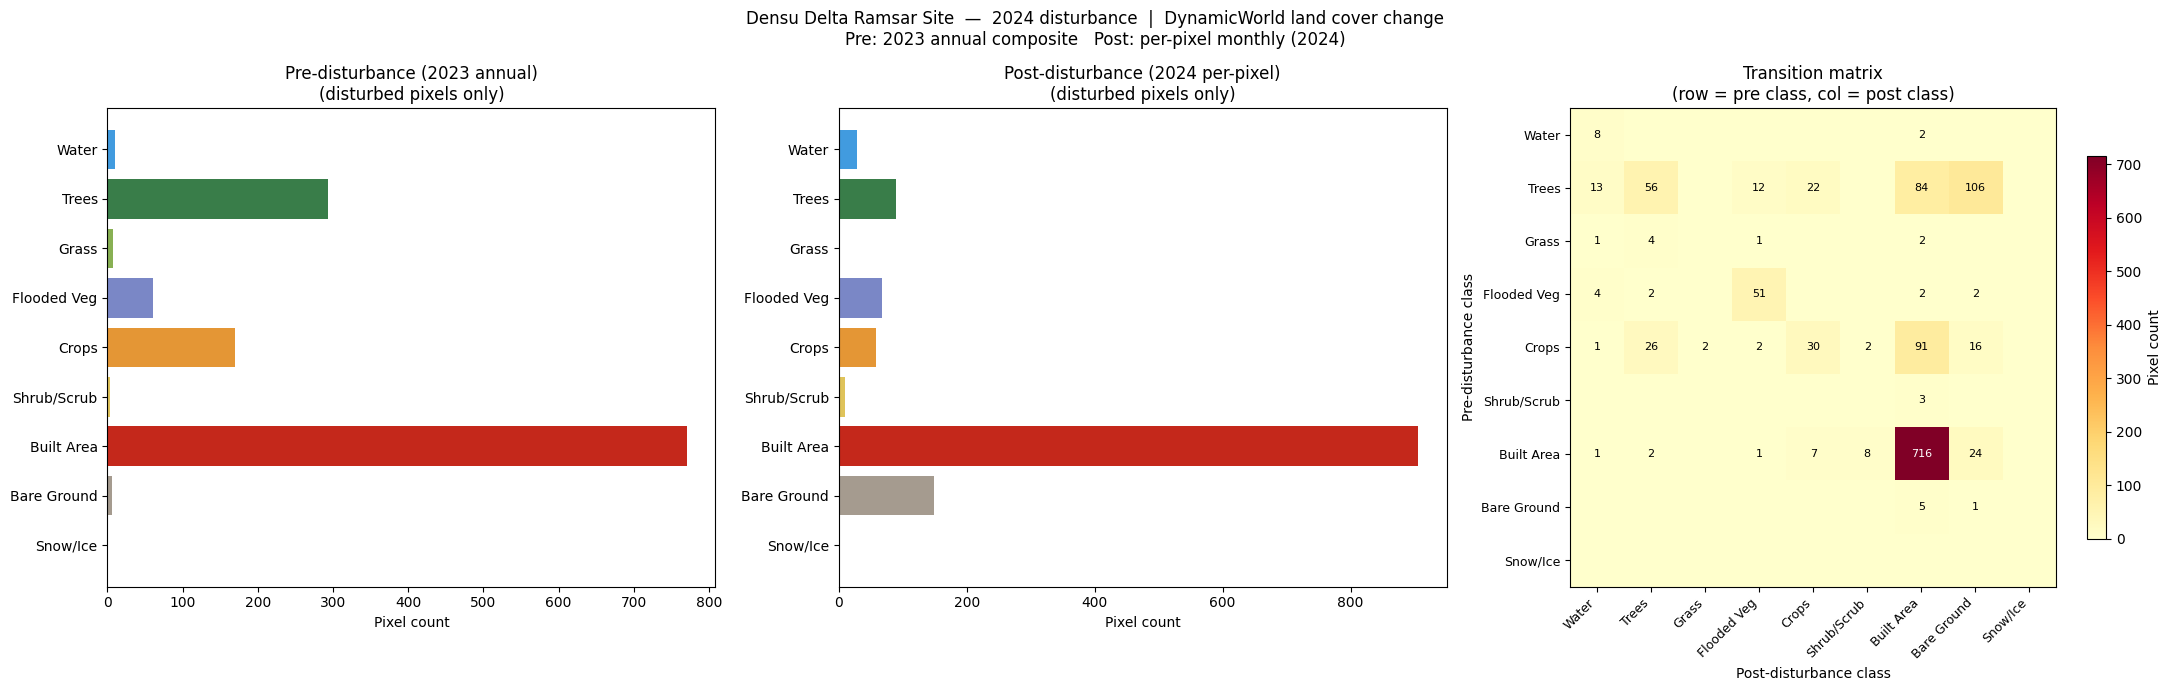

In [ ]:
# single site 
# ID 67967 = Densu Delta PA
# Year - 2024

result = get_single_site_lc_change('2024', 67967, test_sites,
                       anom_lower=30, conf_lower=400, min_post_months=2)

print(f"Site: {result['site_name']}  |  Disturbance year: {result['year']}")


print("\nPre-disturbance land cover at disturbed pixels (2023 annual):")
for cls, n in sorted(result['pre_counts'].items(), key=lambda x: -x[1]):
    print(f"  {cls:<15} {n:>6,}")

print("\nPost-disturbance land cover at disturbed pixels (2024 per-pixel monthly):")
for cls, n in sorted(result['post_counts'].items(), key=lambda x: -x[1]):
    print(f"  {cls:<15} {n:>6,}")

print("\nTransition matrix (rows = pre class, cols = post class):")
print(result['transition_df'])

fig = plot_lc_change(result)
m = visualize_dw_on_map(result)

# by class name
built_to_built = get_transition_mask(result, 'Built Area', 'Built Area')

# or by class integer
crops_to_built = get_transition_mask(result, 4, 6)

# add to map
m.addLayer(built_to_built, {'palette': ['FF6600']}, 'Built → Built', False)
m.addLayer(crops_to_built, {'palette': ['FF0000']}, 'Crops → Built', False)


In [ ]:
empty = ee.Image().byte()


In [ ]:
m

Map(center=[5.534984058891975, -0.3239113244572995], controls=(WidgetControl(options=['position', 'transparent…

## Exporting Land Cover Change Task

In order to run this pre and post disturbance comparison on all sites, it has to be exported as a task to run on google cloud. The best way to do that is to export to a GCS bucket. However, the original development of this notebook exported the file to google drive then requiring the user to download the file locally. <br>
<br>
The cells below WILL NOT run properly in this state because they create a file called tpae_exports on the linked google drive and store the resulting csv there. That file must be downloaded manually and stored somewhere that can be read locally. 
<br>


In [1]:
# # submit task
# task = export_lc_change_multiple_sites('2024', test_sites, description="2024_all_test_sites",
#  folder='tpae_exports')
# task.start()
# print(task.status())  # poll task to ensure it started

In [2]:
# rerun to check status
# print(task.status())

Download the csv and store it somewhere accessible or access directly through google.

In [4]:
# load downloaded lc change csv
# replace filepath with path to csv downloaded from google drive
results_2024 = load_lc_change_site_export("filepath", "2024")

NameError: name 'load_lc_change_site_export' is not defined

In [ ]:
# create dataframes to display results
summary = results_to_summary_df(results_2024)
transitions = results_to_transitions_df(results_2024)

In [ ]:
# Which sites have the most actual land-cover conversion vs. within-class disturbance?
summary.sort_values('pct_changed', ascending=False)

In [ ]:
# Top 10 transitions across all 30 sites
transitions.sort_values('count', ascending=False).head(10)

In [ ]:
# All deforestation-to-development, ranked by site
transitions[(transitions.pre_class == 'Trees') & (transitions.post_class == 'Built Area')]

In [ ]:
# Actual conversions only, aggregated across sites
transitions[~transitions.same_class].groupby(['pre_class', 'post_class'])['count'].sum().sort_values(ascending=False)

In [ ]:
# No real conversion, aggregated across sites
transitions[transitions.same_class].groupby(['pre_class', 'post_class'])['count'].sum().sort_values(ascending=False)

In [ ]:
# % of each site's pixels that genuinely changed class
transitions.groupby('site_name').apply(
    lambda g: g.loc[~g.same_class, 'count'].sum() / g['count'].sum() * 100
).sort_values(ascending=False)

In [ ]:
# filter and display results based on name
plot_lc_change(results_2024['Parc national des Virunga'])

# Testing PSM

This section of the notebook calculates the disturbance rate for match cells treating them as the geometries like the test sites in previous cells. 

In [ ]:
# pull in match table and grids from PSM workflow
# replace filepath with local filepath

match_table_1543 = pd.read_parquet("filepath/match_table_1543.parquet")
matched_grids_1543 = gpd.read_parquet("filepath/matched_grids_1543.parquet")

In [ ]:
# reproject and display matched grid cells

matched_grids_1543 = matched_grids_1543.to_crs(epsg=4326)
matched_grids = geemap.geopandas_to_ee(matched_grids_1543)
display(matched_grids)

In [ ]:
# get site geometry

site_id = 1543
site_geom = selector.get_site_geom(test_sites, site_id)

In [ ]:
# calculate AC dist rate for each grid cell

grid_dist_data = {}
for year in ["2023", "2024", "2025"]:
    grid_dist_data[f"1543_{year}"] = calculate_FeatureCollection_AC_dist_rate(year, 30, 400, matched_grids)


In [ ]:
# merge the results to the grid cells with geometries

grid_dist_df = pd.DataFrame(grid_dist_data["1543_2025"])
merge_keys = ['cell_ID', 'elevation', 'log_pop_density', 'protected', 'slope', 'travel_time', 'treecover2000']
scored = pd.merge(grid_dist_df, matched_grids_1543, on=merge_keys)
scored

In [ ]:
# cast treat_cell_id and control_cell_id as integers

mt = match_table_1543.copy()
mt["treat_cell_id"] = mt["treat_cell_id"].astype(int)
mt["control_cell_id"] = mt["control_cell_id"].astype(int)

In [ ]:
score_cols = ['dist_rate']
scores = scored[["cell_ID"] + score_cols].drop_duplicates("cell_ID").copy()
scores["cell_ID"] = scores["cell_ID"].astype(int)
scores

In [ ]:
# Join cell scores to match table by cell ID
treat_renamed = {"cell_ID": "treat_cell_id", **{c: f"treat_{c}" for c in score_cols}}
ctrl_renamed = {"cell_ID": "control_cell_id", **{c: f"control_{c}" for c in score_cols}}

In [ ]:
match_df = mt.merge(
    scores.rename(columns=treat_renamed), on="treat_cell_id", how="left"
).merge(scores.rename(columns=ctrl_renamed), on="control_cell_id", how="left")

In [ ]:
for col in score_cols:
    match_df[f"{col}_diff"] = match_df[f"treat_{col}"] - match_df[f"control_{col}"]

match_df.head()

In [ ]:
treat_means = match_df.groupby("treat_cell_id")[['dist_rate_diff']].mean()

pa_relative_dist = treat_means['dist_rate_diff'].mean()

print("PA Relative Disturbance Rate", pa_relative_dist)